# 06 — Metric sensitivity

The same model can look strong or weak depending on the evaluation metric.
This notebook pulls paired (model, dataset) rows from the parquet summary
and shows how point-adjust F1 inflates scores vs. point-wise F1 and eTaPR.


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
df = pd.read_parquet(METRICS_DIR / 'summary.parquet')
# Unify F1 column across metrics.
df['F1'] = df['f1'].where(df['metric'] != 'etapr', df['etapr_f1'])
df.groupby(['dataset', 'model', 'metric'])['F1'].mean().round(3).unstack('metric')


metric                    etapr  point_adjust  pointwise
dataset model                                           
hai     dense_ae          0.057         0.477      0.356
        isolation_forest  0.243         0.621      0.185
        lstm_ae           0.147         0.221      0.105
        ocsvm             0.170         0.540      0.265
        tranad            0.276         0.458      0.189
        usad              0.151         0.222      0.107
morris  dense_ae          0.356         0.586      0.253
        isolation_forest  0.145         0.297      0.090
        ocsvm             0.369         0.631      0.275
        tranad            0.339         0.647      0.129
        usad              0.009         0.030      0.001

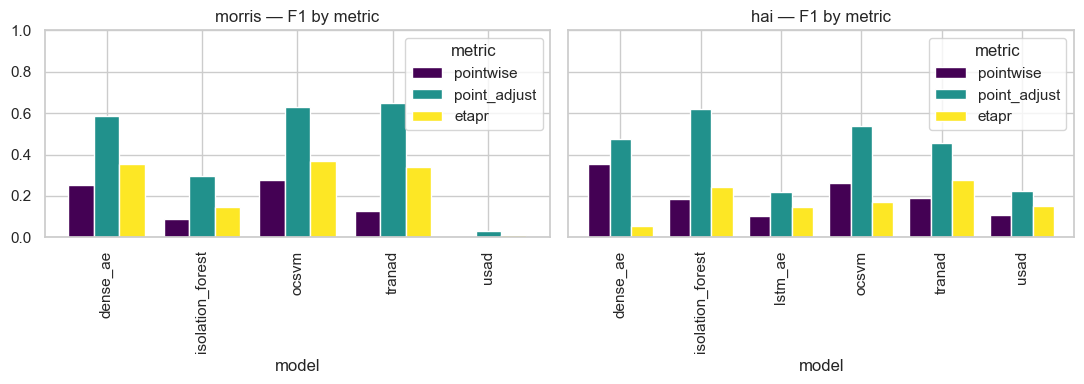

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, ds in zip(axes, df['dataset'].unique()):
    sub = df[df['dataset'] == ds].groupby(['model', 'metric'])['F1'].mean().unstack('metric')
    sub = sub.reindex(columns=['pointwise', 'point_adjust', 'etapr'])
    sub.plot(kind='bar', ax=ax, colormap='viridis', width=0.8)
    ax.set_title(f'{ds} — F1 by metric')
    ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, 'metric_sensitivity', subdir='06_metric_sensitivity')
plt.show()


### Interpretation

- **Point-adjust F1** systematically inflates scores — any single
  detection inside an attack window flips the whole window positive
  (Xu et al. 2018). Kim et al. AAAI 2022 demonstrate this gives random
  scores ~0.98 PA-F1 on common benchmarks.
- **eTaPR** is stricter: it rewards partial overlap proportionally
  rather than awarding full credit for one hit.
- **Point-wise F1** is the most conservative; deployable systems must
  clear this bar rather than the PA bar.
